<a href="https://colab.research.google.com/github/ChAbid-773/Credit_Card_Fruad/blob/main/Credit_Card_Fruad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import os

In [36]:
import kagglehub
path = kagglehub.dataset_download("miadul/credit-card-fraud-detection-dataset")

Using Colab cache for faster access to the 'credit-card-fraud-detection-dataset' dataset.


In [37]:
credit=pd.read_csv(os.path.join(path,'credit_card_fraud_10k.csv'))

In [38]:
credit

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [39]:
from sklearn.preprocessing import LabelEncoder

In [40]:
from sklearn.preprocessing import LabelEncoder
coder=LabelEncoder()

In [41]:
credit['merchant_category']=credit['merchant_category'].astype(str)
credit['merchant_category']=coder.fit_transform(credit['merchant_category'])

In [42]:
credit

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,1,0,0,66,3,40,0
1,2,541.82,3,4,1,0,87,1,64,0
2,3,237.01,17,3,0,0,49,1,61,0
3,4,164.33,4,3,0,1,72,3,34,0
4,5,30.53,15,2,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,2,0,0,99,4,37,0
9996,9997,410.04,5,0,0,0,70,3,25,0
9997,9998,527.75,21,1,0,0,44,2,45,0
9998,9999,91.20,2,1,0,0,38,0,37,0


In [43]:
credit['amount'] = credit['amount'].astype(int)

In [44]:
credit

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84,22,1,0,0,66,3,40,0
1,2,541,3,4,1,0,87,1,64,0
2,3,237,17,3,0,0,49,1,61,0
3,4,164,4,3,0,1,72,3,34,0
4,5,30,15,2,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350,22,2,0,0,99,4,37,0
9996,9997,410,5,0,0,0,70,3,25,0
9997,9998,527,21,1,0,0,44,2,45,0
9998,9999,91,2,1,0,0,38,0,37,0


In [45]:
x=(credit.drop('amount',axis=1))
y=(credit['amount'])

In [46]:
y

,amount
0,84
1,541
2,237
3,164
4,30
...,...
9995,350
9996,410
9997,527
9998,91


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

#**Matplotlib Plot**

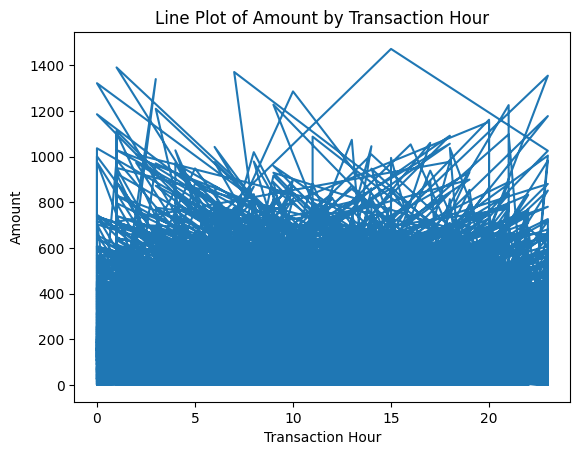

In [48]:
plt.plot(credit['transaction_hour'], credit['amount'])
plt.title('Line Plot of Amount by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

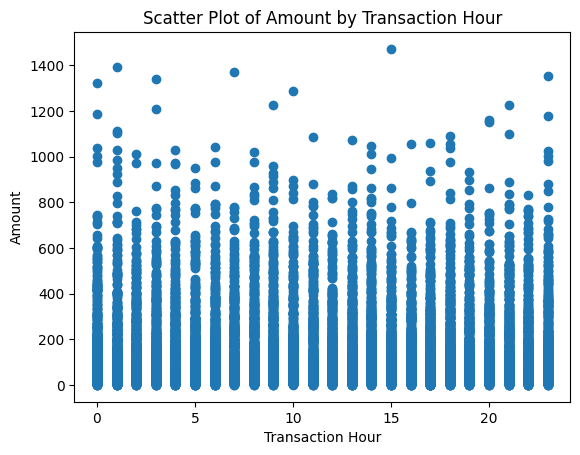

In [49]:
plt.scatter(credit['transaction_hour'], credit['amount'])
plt.title('Scatter Plot of Amount by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

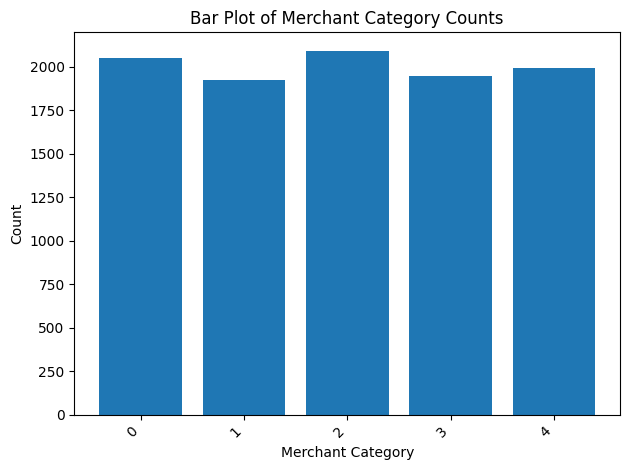

In [50]:
plt.bar(credit['merchant_category'].value_counts().index, credit['merchant_category'].value_counts().values)
plt.title('Bar Plot of Merchant Category Counts')
plt.xlabel('Merchant Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

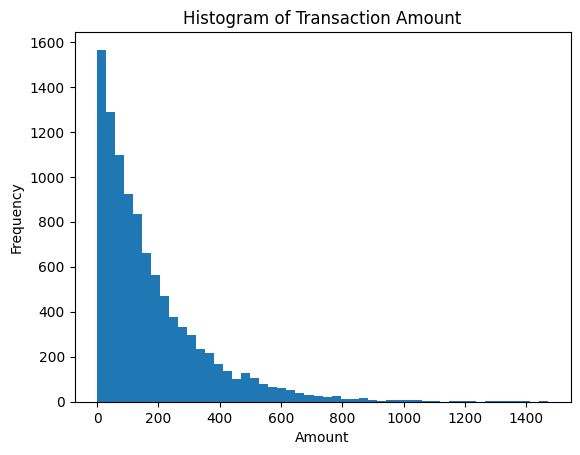

In [51]:
plt.hist(credit['amount'], bins=50)
plt.title('Histogram of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

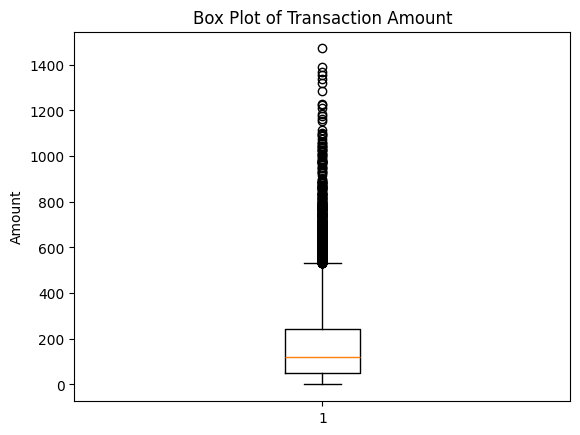

In [52]:
plt.boxplot(credit['amount'])
plt.title('Box Plot of Transaction Amount')
plt.ylabel('Amount')
plt.show()

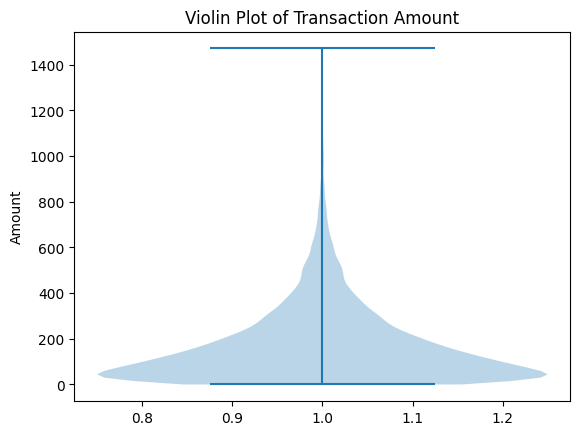

In [53]:
plt.violinplot(credit['amount'])
plt.title('Violin Plot of Transaction Amount')
plt.ylabel('Amount')
plt.show()

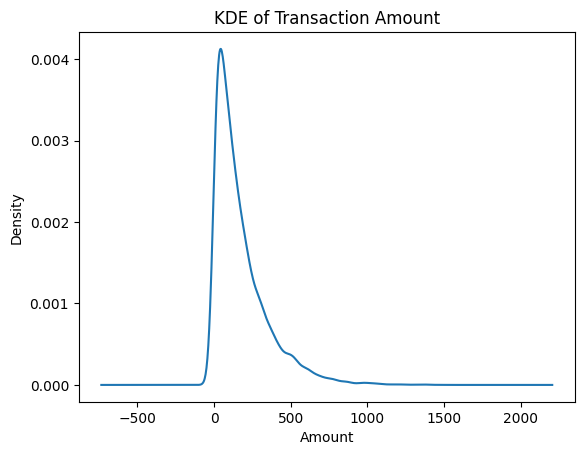

In [54]:
credit['amount'].plot(kind="kde")
plt.title('KDE of Transaction Amount')
plt.xlabel('Amount')
plt.show()

#**Seaborn Plot**

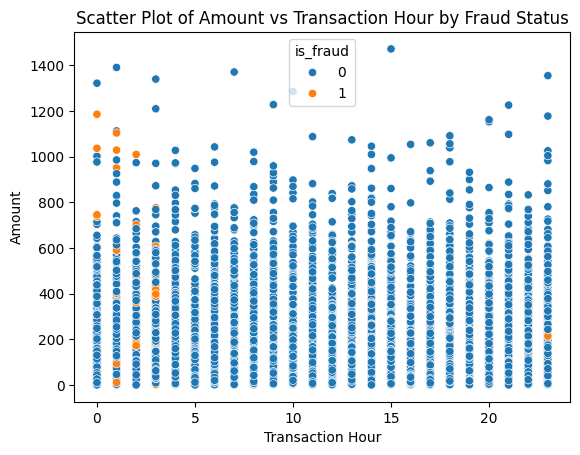

In [55]:
sns.scatterplot(x=credit['transaction_hour'], y=credit['amount'], hue=credit['is_fraud'])
plt.title('Scatter Plot of Amount vs Transaction Hour by Fraud Status')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

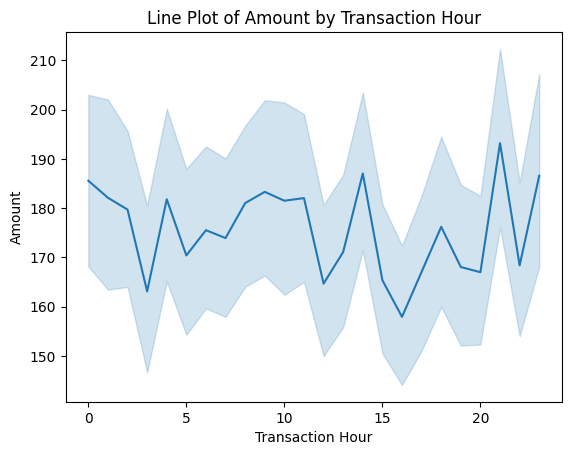

In [56]:
sns.lineplot(x=credit['transaction_hour'], y=credit['amount'])
plt.title('Line Plot of Amount by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Amount')
plt.show()

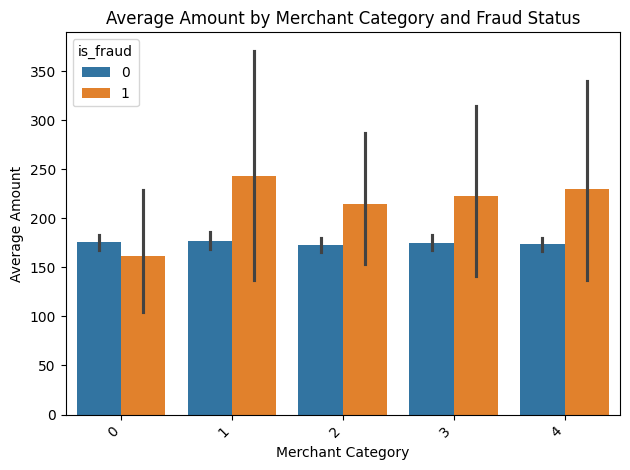

In [57]:
sns.barplot(x=credit['merchant_category'], y=credit['amount'], hue=credit['is_fraud'], estimator=lambda x: x.mean())
plt.title('Average Amount by Merchant Category and Fraud Status')
plt.xlabel('Merchant Category')
plt.ylabel('Average Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

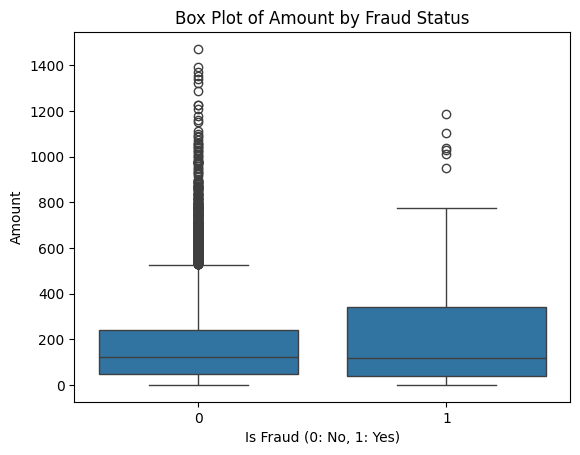

In [58]:
sns.boxplot(x=credit['is_fraud'], y=credit['amount'])
plt.title('Box Plot of Amount by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Amount')
plt.show()

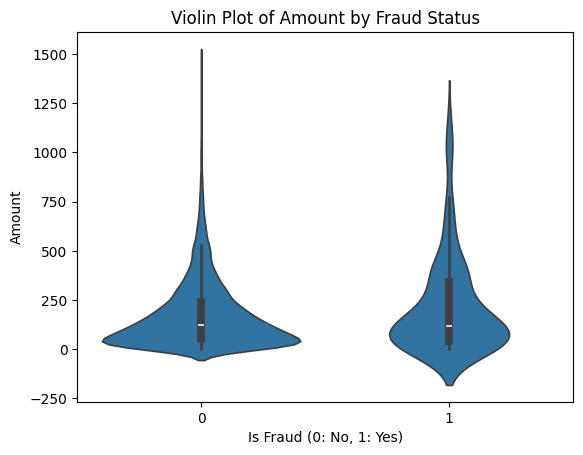

In [59]:
sns.violinplot(x=credit['is_fraud'], y=credit['amount'])
plt.title('Violin Plot of Amount by Fraud Status')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Amount')
plt.show()

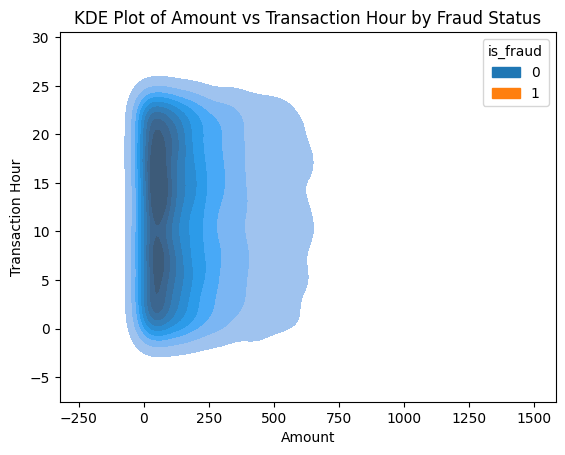

In [60]:
sns.kdeplot(x=credit['amount'], y=credit['transaction_hour'], hue=credit['is_fraud'], fill=True)
plt.title('KDE Plot of Amount vs Transaction Hour by Fraud Status')
plt.xlabel('Amount')
plt.ylabel('Transaction Hour')
plt.show()

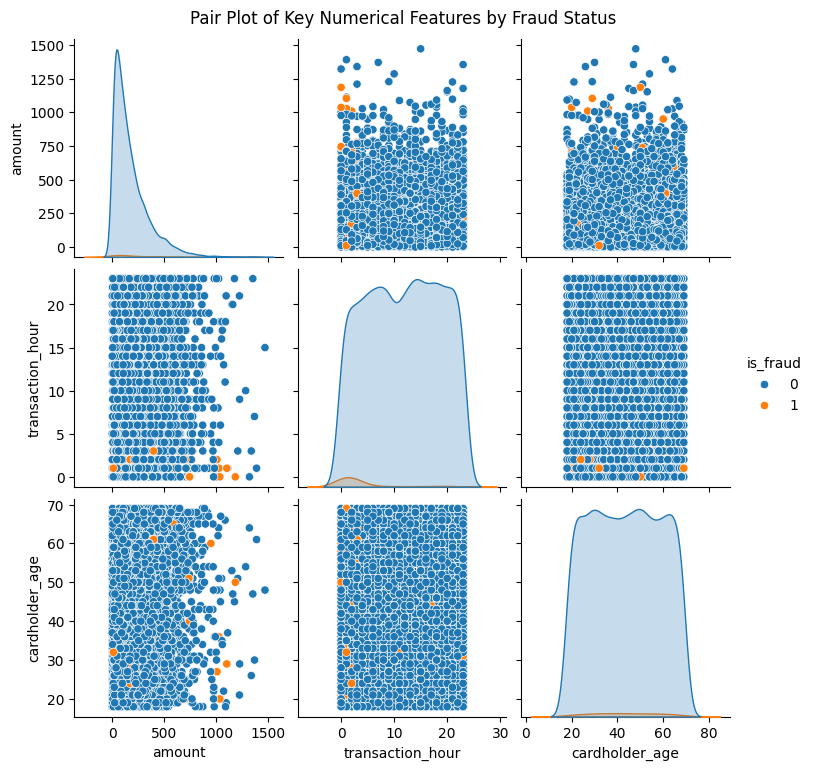

In [61]:
sns.pairplot(credit[['amount', 'transaction_hour', 'cardholder_age', 'is_fraud']], hue='is_fraud')
plt.suptitle('Pair Plot of Key Numerical Features by Fraud Status', y=1.02)
plt.show()

#**Testing and Training**

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [64]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 5048 to 2952
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   transaction_id       8000 non-null   int64
 1   transaction_hour     8000 non-null   int64
 2   merchant_category    8000 non-null   int64
 3   foreign_transaction  8000 non-null   int64
 4   location_mismatch    8000 non-null   int64
 5   device_trust_score   8000 non-null   int64
 6   velocity_last_24h    8000 non-null   int64
 7   cardholder_age       8000 non-null   int64
 8   is_fraud             8000 non-null   int64
dtypes: int64(9)
memory usage: 625.0 KB


In [65]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 7481 to 6593
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   transaction_id       2000 non-null   int64
 1   transaction_hour     2000 non-null   int64
 2   merchant_category    2000 non-null   int64
 3   foreign_transaction  2000 non-null   int64
 4   location_mismatch    2000 non-null   int64
 5   device_trust_score   2000 non-null   int64
 6   velocity_last_24h    2000 non-null   int64
 7   cardholder_age       2000 non-null   int64
 8   is_fraud             2000 non-null   int64
dtypes: int64(9)
memory usage: 156.2 KB


In [66]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 8000 entries, 5048 to 2952
Series name: amount
Non-Null Count  Dtype
--------------  -----
8000 non-null   int64
dtypes: int64(1)
memory usage: 125.0 KB


In [67]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 2000 entries, 7481 to 6593
Series name: amount
Non-Null Count  Dtype
--------------  -----
2000 non-null   int64
dtypes: int64(1)
memory usage: 31.2 KB


#**Linear Regression**

In [68]:
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(x_train,y_train)
y_pred1=model1.predict(x_test)
print(y_pred1)

[173.77959481 165.80102165 198.37537138 ... 179.88120356 178.64596286
 172.59320491]


In [69]:
df1=pd.DataFrame({'Actual':y_test,'Predicted':y_pred1}).reset_index(drop=True)
df1

,Actual,Predicted
0,26,173.779595
1,313,165.801022
2,569,198.375371
3,49,175.650272
4,76,177.124169
...,...,...
1995,14,175.416029
1996,53,167.427456
1997,111,179.881204
1998,3,178.645963


In [71]:
model1.predict([[1,2,4,2,5,6,2,2,5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([298.24189507])

#**K Means**

In [72]:
from sklearn.cluster import KMeans
model2=KMeans(n_clusters=2)
model2.fit(x_train,y_train)
y_pred2=model2.predict(x_test)
print(y_pred2)

[0 1 1 ... 0 1 0]


In [73]:
df2=pd.DataFrame({'Actual':y_test,'Predicted':y_pred2}).reset_index(drop=True)
df2


,Actual,Predicted
0,26,0
1,313,1
2,569,1
3,49,1
4,76,1
...,...,...
1995,14,1
1996,53,1
1997,111,0
1998,3,1


In [74]:
model2.predict([[1,2,4,2,5,6,2,2,5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([1], dtype=int32)

#**Decision Tree**

In [75]:
from sklearn.tree import DecisionTreeClassifier
model3=DecisionTreeClassifier()
model3.fit(x_train,y_train)
y_pred3=model3.predict(x_test)
print(y_pred3)

[107  56 630 ... 222  65  19]


In [76]:
df3=pd.DataFrame({'Actual':y_test,'Predicted':y_pred3}).reset_index(drop=True)
df3

,Actual,Predicted
0,26,107
1,313,56
2,569,630
3,49,18
4,76,662
...,...,...
1995,14,5
1996,53,265
1997,111,222
1998,3,65


In [77]:
model3.predict([[1,2,4,2,5,6,2,2,5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([164])

#**Random Forest**

In [78]:
from sklearn.ensemble import RandomForestClassifier
model4=RandomForestClassifier()
model4.fit(x_train,y_train)
y_pred4=model4.predict(x_test)
print(y_pred4)

[ 19  56 342 ... 222  15 274]


In [79]:
df4=pd.DataFrame({'Actual':y_test,'Predicted':y_pred4}).reset_index(drop=True)
df4

,Actual,Predicted
0,26,19
1,313,56
2,569,342
3,49,171
4,76,305
...,...,...
1995,14,41
1996,53,97
1997,111,222
1998,3,15


In [80]:
model4.predict([[1,2,4,2,5,6,2,2,5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([57])